In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("C:/Users/Lenovo/Downloads/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
#To know the data set information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
# We want to calculate the how many groups are present  
df['race/ethnicity'].value_counts()

group C    319
group D    262
group B    190
group E    140
group A     89
Name: race/ethnicity, dtype: int64

In [6]:
#
df['parental level of education'].value_counts()

some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: parental level of education, dtype: int64

In [13]:
#Avg score of different group in different subjects
avg_score = df.groupby(['race/ethnicity'])['math score','reading score','writing score'].mean()
avg_score

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3588\4152030741.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  avg_score = df.groupby(['race/ethnicity'])['math score','reading score','writing score'].mean()


,math score,reading score,writing score
race/ethnicity,,,
group A,61.629213,64.674157,62.674157
group B,63.452632,67.352632,65.600000
group C,64.463950,69.103448,67.827586
group D,67.362595,70.030534,70.145038
group E,73.821429,73.028571,71.407143


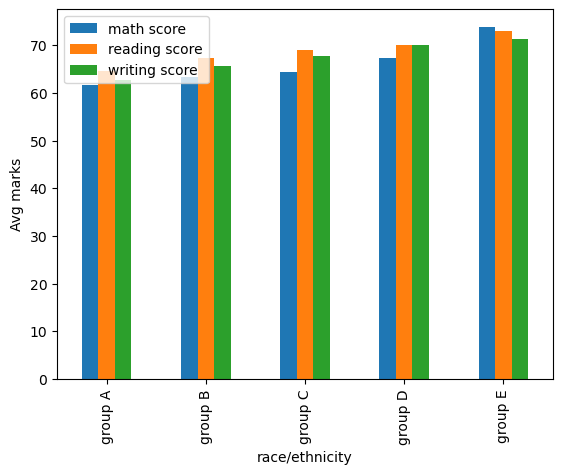

In [20]:
avg_score.plot(kind='bar')
plt.ylabel("Avg marks")
plt.legend(loc='upper left')
plt.show()

**Overall performance in all the groups, Group E has best performance and scored highest in all subjects**

* In each group reading score is highest except e group where math score is best

* From this plot we can conclude that the math is tough subject


In [23]:
##Create Total & Average Score
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average score'] = df['total score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [26]:
# Create composite scores
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average score'] = df['total score'] / 3

# 1. Performance bands
bins = [0, 49, 69, 79, 100]
labels = ['Struggling (0-49)', 'Average (50-69)', 'Good (70-79)', 'Excellent (80-100)']
df['performance band'] = pd.cut(df['average score'], bins=bins, labels=labels, include_lowest=True)

# 2. Pass rate (threshold ≥50)
df['pass'] = df['average score'] >= 50
pass_rate = df['pass'].mean() * 100

# 3. Top-performer ratio (average ≥90)
top_ratio = (df['average score'] >= 90).mean() * 100

# 4. Test prep effect size (score lift)
prep_lift = df.groupby('test preparation course')['average score'].mean()
score_lift = prep_lift.get('completed', 0) - prep_lift.get('none', 0)

# 5. Equity gaps
lunch_gap = df.groupby('lunch')['average score'].mean()
equity_lunch_gap = lunch_gap.get('standard', 0) - lunch_gap.get('free/reduced', 0)

parent_gap = df.groupby('parental level of education')['average score'].mean()
equity_parent_gap = parent_gap.get("bachelor's degree", 0) - parent_gap.get("high school", 0)

# 6. Consistency index (scores within 10 points)
df['consistent learner'] = (
    df[['math score', 'reading score', 'writing score']].max(axis=1) -
    df[['math score', 'reading score', 'writing score']].min(axis=1)
) <= 10
consistency_ratio = df['consistent learner'].mean() * 100

# 7. Subject mastery rate (≥75)
mastery_math = (df['math score'] >= 75).mean() * 100
mastery_read = (df['reading score'] >= 75).mean() * 100
mastery_write = (df['writing score'] >= 75).mean() * 100

# 8. Risk indicator score (2+ risk conditions)
df['risk count'] = (
    (df['lunch'] == 'free/reduced').astype(int) +
    (df['test preparation course'] == 'none').astype(int) +
    (df['math score'] < 50).astype(int)
)
df['at risk'] = df['risk count'] >= 2
risk_ratio = df['at risk'].mean() * 100

# 9. Percentile rank
df['percentile rank'] = df['average score'].rank(pct=True) * 100

# 10. Prep completion rate by category
prep_access = df.groupby(['lunch','parental level of education','race/ethnicity'])['test preparation course'] \
    .apply(lambda x: (x=='completed').mean()*100)

# 11. Score distribution shape
skew_math = stats.skew(df['math score'])
skew_read = stats.skew(df['reading score'])
skew_write = stats.skew(df['writing score'])

kurt_math = stats.kurtosis(df['math score'])
kurt_read = stats.kurtosis(df['reading score'])
kurt_write = stats.kurtosis(df['writing score'])

# Print key metrics
print(f"Pass Rate: {pass_rate:.2f}%")
print(f"Top Performer Ratio (Avg ≥90): {top_ratio:.2f}%")
print(f"Test Prep Score Lift: {score_lift:.2f} points")
print(f"Educator Equity Gap (Lunch Type): {equity_lunch_gap:.2f} points")
print(f"Educator Equity Gap (Parent Education - Bachelor's vs HS): {equity_parent_gap:.2f} points")
print(f"Consistency Index: {consistency_ratio:.2f}% of students")
print(f"Math Mastery Rate (≥75): {mastery_math:.2f}%")
print(f"Reading Mastery Rate (≥75): {mastery_read:.2f}%")
print(f"Writing Mastery Rate (≥75): {mastery_write:.2f}%")
print(f"At-Risk Student Ratio: {risk_ratio:.2f}%")
print("\nPrep Completion Rate by Category (Lunch | Parent Education | Race/Ethnicity):")
print(prep_access.head(10))
print("\nScore Skewness (Math, Reading, Writing):", skew_math, skew_read, skew_write)
print("Score Kurtosis (Math, Reading, Writing):", kurt_math, kurt_read, kurt_write)

Pass Rate: 89.70%
Top Performer Ratio (Avg ≥90): 5.20%
Test Prep Score Lift: 7.63 points
Educator Equity Gap (Lunch Type): 8.64 points
Educator Equity Gap (Parent Education - Bachelor's vs HS): 8.83 points
Consistency Index: 59.60% of students
Math Mastery Rate (≥75): 29.50%
Reading Mastery Rate (≥75): 37.00%
Writing Mastery Rate (≥75): 35.00%
At-Risk Student Ratio: 28.30%

Prep Completion Rate by Category (Lunch | Parent Education | Race/Ethnicity):
lunch         parental level of education  race/ethnicity
free/reduced  associate's degree           group A           28.571429
                                           group B           35.714286
                                           group C           36.363636
                                           group D           33.333333
                                           group E           53.846154
              bachelor's degree            group A           50.000000
                                           group B           

## Academic Performance Snapshot
* Overall Pass Rate (Avg ≥50): 89.7%

* Insight: The cohort shows a high pass outcome, indicating general academic competence. Focus should shift from broad remediation to mastery improvement and equity-driven interventions.

* Top Performer Ratio (Avg ≥90): 5.2%

* Insight: A small but significant group achieves excellence. These students can be studied to uncover success patterns that can be replicated.


## Actionable Learning & Support Indicators
* Test Preparation Score Lift: +7.63 points
* Insight: Test preparation yields a meaningful improvement, making it the strongest actionable lever for boosting student outcomes.

* Consistency Index: 59.6% of students
* Insight: More than half of students maintain balanced performance across subjects, suggesting stable learning behavior rather than extreme subject disparity.



## Equity & Access Gaps
* Lunch Equity Gap: 8.64 points
* Insight: Students on standard lunch outperform free/reduced lunch peers, confirming a measurable socioeconomic achievement gap.

* Parent Education Equity Gap (Bachelor’s vs High School): 8.83 points
* Insight: Parental education level strongly aligns with student performance, highlighting the role of home academic environment and exposure.

## Access to Test Preparation (By Demographics)
* Key patterns from segmented prep completion:

* Students on free/reduced lunch with bachelor-educated parents in Group E show the highest prep access (75%)
* Group E students consistently lead in prep participation, regardless of parent education level
* Some groups (e.g., Group B under bachelor parents) show very low access (11.1%), indicating uneven academic support distribution
* Insight: Academic support opportunities are not evenly accessed across student groups, signaling a need for policy emphasis on equal preparation access.

## Statistical Score Behavior
* Score Skewness: Math (-0.28), Reading (-0.26), Writing (-0.29)
* Insight: Slight negative skew shows more students cluster at higher scores, with fewer extreme low performers.

* Score Kurtosis: Math (0.27), Reading (-0.07), Writing (-0.04)
* Insight: Near-normal kurtosis suggests limited extreme outliers, supporting model stability and reliable inference.

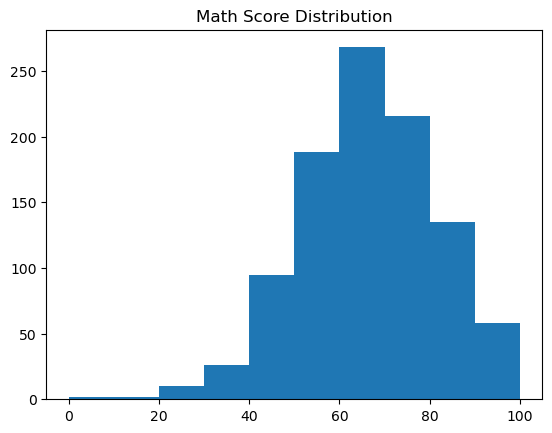

In [27]:
plt.figure()
plt.hist(df['math score'])
plt.title("Math Score Distribution")
plt.show()

* Insight: Distribution likely shows a mild left skew with visible low-score tail, confirming math is the weakest subject and contains more struggling students.

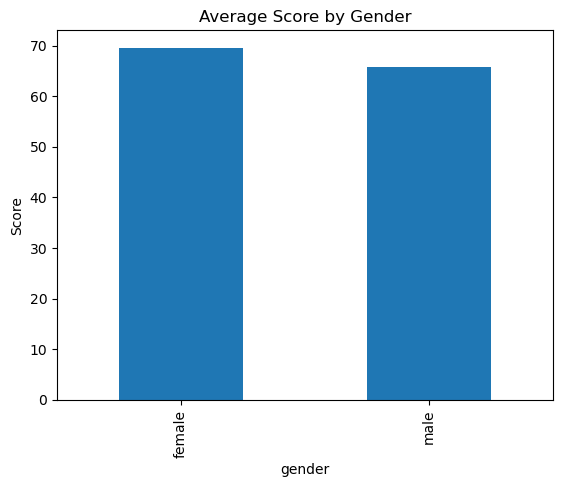

In [28]:
plt.figure()
df.groupby('gender')['average score'].mean().plot(kind='bar')
plt.title("Average Score by Gender")
plt.ylabel("Score")
plt.show()

* Insight: Females lead overall average performance, driven by stronger Reading and Writing scores despite males performing slightly better in Math.

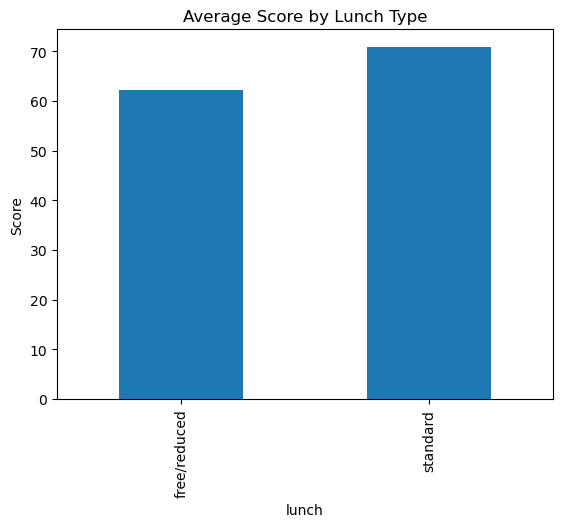

In [29]:
plt.figure()
df.groupby('lunch')['average score'].mean().plot(kind='bar')
plt.title("Average Score by Lunch Type")
plt.ylabel("Score")
plt.show()

* Insight: Standard lunch students outperform free/reduced lunch students, reinforcing that economic advantage aligns with higher academic achievement.

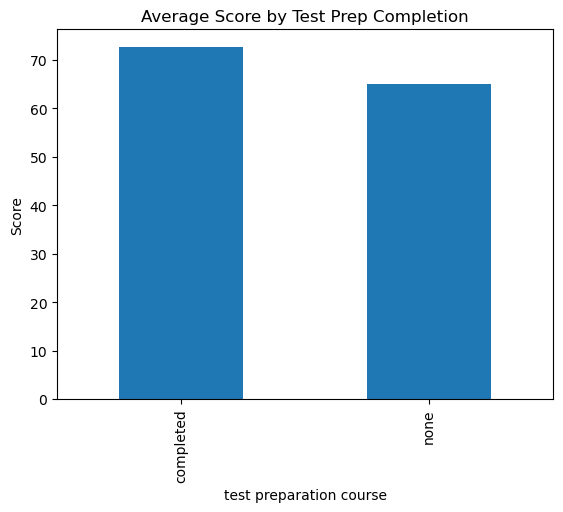

In [30]:
plt.figure()
df.groupby('test preparation course')['average score'].mean().plot(kind='bar')
plt.title("Average Score by Test Prep Completion")
plt.ylabel("Score")
plt.show()

* Insight: Completing test preparation significantly boosts performance — one of the strongest actionable drivers in the dataset.

## Final Insights & Recommendations¶
* This analysis shows that student performance is strongly influenced by structured academic support and socioeconomic conditions.

### Key educator takeaways

* Test preparation improves scores by +7.63 points, making it the most effective, scalable intervention metric.
* Math has the lowest mastery rate (29.5%), signaling it as the top subject requiring curriculum improvement.
* Socioeconomic proxies (lunch type and parent education) reveal ~8.7–8.8 point performance gaps, validating equity concerns.
* Group E contains the highest concentration of well-supported and high-scoring students, suggesting a model group for extracting replicable success strategies.
* Uneven access to test prep across demographics confirms support inequality, a critical insight for education stakeholders.

### Recommendations

* Increase test preparation access, prioritizing underserved groups.
* Implement math mastery support programs.
* Use early-warning risk indicators (28.3% flagged) to drive timely interventions.
* Build dashboards highlighting mastery, equity, and intervention lift not just averages.